# Cross-Data-Type 1-D CNN (Wang et al., 2021)

**Реализация для НИР:** Торговая стратегия на основе моделей глубокого обучения для российского рынка

Статья: *Financial Markets Prediction with Deep Learning* (arXiv:2104.05413)

### Ключевые отличия от базовой модели
| Параметр | Базовая (models.ipynb) | CDT 1-D CNN (Wang et al.) |
|---|---|---|
| Архитектура | 2 Conv1D (64, 128) | 3 Conv1D (32, 64, 128) + BatchNorm |
| Ядра | 3×64, 3×128 | 4×32, 3×64, 2×128 |
| FC слои | 512 | 1000 → 500 |
| Dropout | 0.2 | 0.7 |
| Метрика | Accuracy | Weighted F-Score |
| Обучение | 48 мес + fine-tune | Moving windows (2 года + 4 нед val + 2 нед test) |
| Разметка | ±ασ (α=2) | ±αv_t (α=0.55, Eq.8) |

In [13]:
# Установка зависимостей (раскомментировать при необходимости)
# !pip install tensorflow scikit-learn matplotlib pandas pyarrow

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from dateutil.relativedelta import relativedelta

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from sklearn.preprocessing import StandardScaler

import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")

TensorFlow: 2.15.0
GPU: []


## 1. Параметры (по статье Wang et al.)

In [15]:
# === Параметры из статьи (Section IV, V) ===
WINDOW_SIZE = 24        # 24 свечи = 2 часа (5-мин данные)
ALPHA = 0.55            # Параметр для динамической разметки (Eq. 8)
TRAIN_RECORDS = 142_416 # ~2 года (из статьи)
VAL_RECORDS = 192       # 4 недели
TEST_RECORDS = 96       # 2 недели
STEP_RECORDS = 96       # Шаг скользящего окна

LEARNING_RATE = 1e-3
DROPOUT_RATE = 0.7
L2_DECAY = 1e-5
BATCH_SIZE = 12
EPOCHS = 15
CONFIDENCE_THRESHOLD = 0.65

# Weighted F-Score (Section IV-B2)
BETA1 = 0.5
BETA2 = 0.125
BETA3 = 0.125

## 2. Предобработка данных

In [16]:
# Функции предобработки загружаются из основного скрипта
# (см. cdt_1d_cnn_wang.py для полного кода)
from cdt_1d_cnn_wang import (
    clean_market_data, fill_time_gaps, add_technical_indicators,
    create_labels, create_tensors_cdt,
    build_cdt_1d_cnn, build_baseline_cnn,
    weighted_f_score, run_moving_window_backtest,
    plot_results_comparison, print_summary_table
)

## 3. Загрузка и подготовка данных

In [17]:
# === Загрузка данных ===
ticker = "YDEX"  # Можно менять: SBER, LKOH, MGNT, GLDRUB_TOM и т.д.
df = pd.read_parquet(f"data/{ticker}_5min.parquet")
df = df[df["DateTime"] >= "2020-01-01"]
df = df[df["DateTime"] < "2026-01-01"]
df = fill_time_gaps(df)
df = clean_market_data(df)
print(f"Тикер: {ticker}")
print(f"Данные: {len(df)} строк")
print(f"Период: {df['DateTime'].min()} — {df['DateTime'].max()}")
print(f"Первые строки:")
df.head()

Тикер: YDEX
Данные: 630348 строк
Период: 2020-01-03 06:55:00 — 2025-12-30 23:50:00
Первые строки:


,DateTime,Open,High,Low,Close,Volume
0,2020-01-03 06:55:00,2713.0,2713.0,2713.0,2713.0,10.0
1,2020-01-03 07:00:00,2712.0,2718.0,2697.5,2717.0,7907.0
2,2020-01-03 07:05:00,2717.0,2717.5,2710.0,2712.0,2587.0
3,2020-01-03 07:10:00,2712.0,2714.0,2710.5,2714.0,2516.0
4,2020-01-03 07:15:00,2714.0,2715.0,2703.0,2704.5,4203.0


In [18]:
# === Данные с техническими индикаторами (46 атрибутов, как в статье) ===
df_with_ti = add_technical_indicators(df.copy())
base_features = ["Open", "High", "Low", "Close", "Volume"]
ti_features = [c for c in df_with_ti.columns if c not in ["DateTime", "Target"]]
print(f"Признаки без TI: {len(base_features)}")
print(f"Признаки с TI:   {len(ti_features)}")
print(f"Список TI: {[f for f in ti_features if f not in base_features]}")

Признаки без TI: 5
Признаки с TI:   31
Список TI: ['EMA_5', 'EMA_10', 'EMA_20', 'EMA_50', 'MACD_Hist_12_26', 'MACD_Hist_5_15', 'BB_Upper_10', 'BB_Lower_10', 'BB_Width_10', 'BB_Upper_20', 'BB_Lower_20', 'BB_Width_20', 'RSI_7', 'RSI_14', 'RSI_21', 'CCI_14', 'CCI_20', 'VWAP', 'OBV', 'ADX_14', 'ADL', 'CMF_10', 'CMF_20', 'ROC_5', 'ROC_10', 'ROC_20']


## 4. Разметка по Wang et al. (Equation 8)

Распределение классов (разметка Wang et al., α=0.55):
  Flat: 474304 (75.2%)
  Up: 78342 (12.4%)
  Down: 77702 (12.3%)


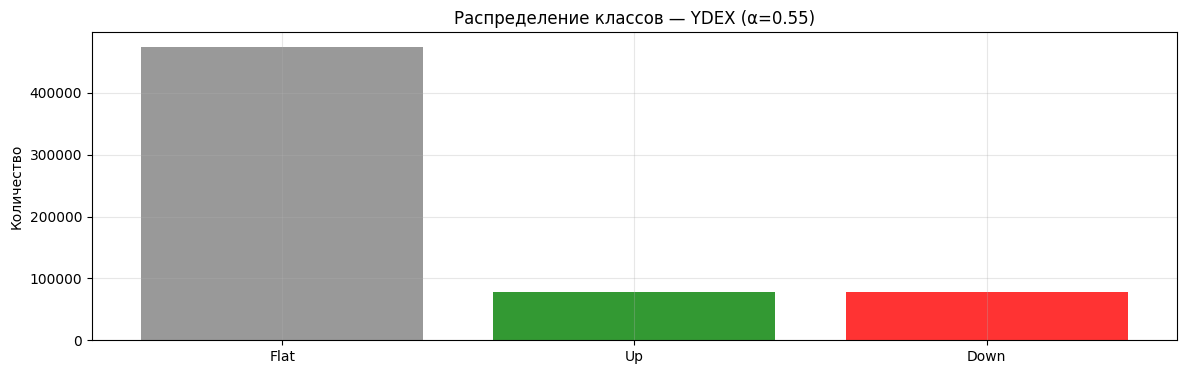

In [19]:
# === Визуализация разметки ===
labels = create_labels(df, alpha=ALPHA)
unique, counts = np.unique(labels, return_counts=True)
print("Распределение классов (разметка Wang et al., α=0.55):")
for u, c in zip(unique, counts):
    lbl = {0: "Flat", 1: "Up", 2: "Down"}[u]
    print(f"  {lbl}: {c} ({c/len(labels)*100:.1f}%)")

plt.figure(figsize=(14, 4))
plt.bar(["Flat", "Up", "Down"], counts, color=["gray", "green", "red"], alpha=0.8)
plt.title(f"Распределение классов — {ticker} (α={ALPHA})")
plt.ylabel("Количество")
plt.grid(alpha=0.3)
plt.show()

## 5. Архитектура CDT 1-D CNN

In [20]:
# === Просмотр архитектуры ===
model_demo = build_cdt_1d_cnn(n_features=5, window_size=WINDOW_SIZE)
model_demo.summary()
print(f"Всего параметров: {model_demo.count_params():,}")

Model: "CDT_1D_CNN"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_frame (InputLayer)    [(None, 24, 5)]           0         
                                                                 
 cdt_conv1 (Conv1D)          (None, 24, 32)            672       
                                                                 
 bn1 (BatchNormalization)    (None, 24, 32)            128       
                                                                 
 pool1 (MaxPooling1D)        (None, 6, 32)             0         
                                                                 
 cdt_conv2 (Conv1D)          (None, 6, 64)             6208      
                                                                 
 bn2 (BatchNormalization)    (None, 6, 64)             256       
                                                                 
 pool2 (MaxPooling1D)        (None, 2, 64)             0

## 6. Запуск бэктеста — 3 модели

In [21]:
results_all = []

# === Модель 1: CDT 1-D CNN без TI (лучший результат в статье) ===
print("" + "="*70)
print("  МОДЕЛЬ 1: CDT 1-D CNN без технических индикаторов")
print("="*70)
res1 = run_moving_window_backtest(
    df=df.copy(),
    feature_cols=base_features,
    model_builder=build_cdt_1d_cnn,
    model_name="CDT 1-D CNN w/o TIs",
    alpha=ALPHA
)
if res1:
    results_all.append(res1)

  МОДЕЛЬ 1: CDT 1-D CNN без технических индикаторов

  БЭКТЕСТ: CDT 1-D CNN w/o TIs
  Признаки: 5 | Окно: 24 | α=0.55


Всего точек: 630323 | Форма входа: (630323, 24, 5)
  Класс Flat: 474285 (75.2%)
  Класс Up: 78340 (12.4%)
  Класс Down: 77698 (12.3%)

Moving Window: train=142416, val=192, test=96, step=96


  Сессия 10: обработано 960 точек...


  Сессия 20: обработано 1920 точек...


  Сессия 30: обработано 2880 точек...


KeyboardInterrupt: 

In [ ]:
# === Модель 2: CDT 1-D CNN с TI ===
print("" + "="*70)
print("  МОДЕЛЬ 2: CDT 1-D CNN с техническими индикаторами")
print("="*70)
res2 = run_moving_window_backtest(
    df=df_with_ti.copy(),
    feature_cols=ti_features,
    model_builder=build_cdt_1d_cnn,
    model_name="CDT 1-D CNN w/ TIs",
    alpha=ALPHA
)
if res2:
    results_all.append(res2)

In [ ]:
# === Модель 3: Baseline 1-D CNN (текущая архитектура из models.ipynb) ===
print("" + "="*70)
print("  МОДЕЛЬ 3: Baseline 1-D CNN (текущая модель)")
print("="*70)
res3 = run_moving_window_backtest(
    df=df.copy(),
    feature_cols=base_features,
    model_builder=build_baseline_cnn,
    model_name="Baseline 1-D CNN",
    alpha=ALPHA
)
if res3:
    results_all.append(res3)

## 7. Сводные результаты (аналог Table I, Fig. 3, 4, 5 из статьи)

In [ ]:
# === Сводная таблица ===
print_summary_table(results_all)

# === Графики ===
plot_results_comparison(results_all, ticker=ticker)

## 8. Запуск на нескольких тикерах (аналог 6 фьючерсов в статье)

In [ ]:
# Раскомментировать для запуска на всех тикерах
# tickers = ["SBER", "LKOH", "MGNT", "VTBR", "TATN", "GLDRUB_TOM"]
# all_ticker_results = {}
# for t in tickers:
#     print(f"{"="*70}")
#     print(f"  ТИКЕР: {t}")
#     print(f"{"="*70}")
#     try:
#         df_t = pd.read_parquet(f"data/{t}_5min.parquet")
#         df_t = df_t[df_t["DateTime"] < "2026-01-01"]
#         df_t = fill_time_gaps(df_t)
#         df_t = clean_market_data(df_t)
#         res = run_moving_window_backtest(
#             df=df_t, feature_cols=base_features,
#             model_builder=build_cdt_1d_cnn,
#             model_name=f"CDT-CNN {t}", alpha=ALPHA
#         )
#         if res:
#             all_ticker_results[t] = res
#     except Exception as e:
#         print(f"  Ошибка для {t}: {e}")

Wang J. et al. *Financial Markets Prediction with Deep Learning* // arXiv:2104.05413 (2021)